# Clase 12 — Pandas. Clasificador de Morosidad con KNN. 

Hasta ahora usamos pandas para explorar y preparar datos. Hoy vamos a usar un dataset real de solicitudes de crédito para entrenar un modelo que responda una pregunta concreta: **¿esta solicitud corresponde a una persona morosa?**

La columna objetivo es `moroso`: `0` significa que no es moroso y `1` que sí lo es. El objetivo didáctico no es construir un sistema de crédito para producción, sino recorrer el flujo completo de clasificación con datos reales.

**Objetivos de la clase:**
- Cargar y explorar un CSV de créditos con pandas.
- Visualizar dos variables antes de entrenar.
- Preparar variables numéricas, incluyendo un valor faltante.
- Separar train/test y entrenar un clasificador KNN.
- Evaluar el modelo con una matriz de confusión y predecir una nueva solicitud.

---
## 1. Cargar y conocer el dataset

Cada fila representa una solicitud. Además de la edad y los ingresos, hay datos de deuda, cuotas, consultas y situación crediticia. Cargamos el archivo y miramos algunas filas antes de tomar decisiones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

creditos = pd.read_csv("dataset_credito.csv")

print("Forma del dataset (filas, columnas):", creditos.shape)

display(creditos.head())

Forma del dataset (filas, columnas): (1190, 26)


,ID,ingresos,edad,provincia_codigo,bancarizado,BCRA_Peor_Situacion,Cantidad_consultas_7_dias,Compromisos_Mensual,Endeudamiento_Externo,Nivel_Socioeconomico,...,autonomo,Es_jubilado,relacion_dependencia,dias_atraso,Cuota,cant_cuotas,Monto_Otorgado,PRODUCTO,PROVINCIA,moroso
0,1,35000.0,35,X,1,1,1.0,9976.0,170000.0,4,...,F,F,UNIVERSIDAD NACIONAL DE CORDOBA ...,143,8957.00,12,50000.0,DS_SUCURSAL_ORO,CORDOBA,1
1,2,50000.0,24,B,1,3,0.0,16807.0,236000.0,4,...,F,F,POLICIA FEDERAL ARGENTINA ...,174,6874.49,9,25000.0,DS_BASICO,BUENOS AIRES,1
2,3,50000.0,42,X,1,1,5.0,42959.0,683343.0,3,...,F,F,MINISTERIO DE EDUCACION ...,0,4191.93,12,23400.0,DS_SUCURSAL_ORO,CORDOBA,0
3,4,32000.0,21,H,1,1,3.0,7583.0,76000.0,5,...,F,F,CONTADURIA GENERAL DEL EJERCITO ...,23,3667.60,12,16000.0,DS_BASICO,CHACO,0
4,5,50000.0,21,Z,1,1,4.0,1040.0,23000.0,5,...,F,F,CONTADURIA GENERAL DEL EJERCITO ...,0,3891.04,6,15000.0,DS_SUCURSAL_ORO,SANTA CRUZ,0


---
## 2. Exploración inicial de datos (EDA)

Antes de elegir un modelo conviene hacer una exploración breve y ordenada. El EDA (*Exploratory Data Analysis*) no busca responder todo: busca detectar problemas que podrían volver inválido el análisis o el entrenamiento.

Vamos a responder, en este orden:

1. ¿Qué columnas tenemos y qué tipo de dato interpreta pandas?
2. ¿Hay faltantes o filas duplicadas?
3. ¿Cómo se distribuyen los números y nuestra variable objetivo?
4. ¿Qué variables conviene usar en este primer modelo?

In [6]:
# 2.1 Estructura y tipos de datos
# info() muestra cantidad de valores no nulos y el tipo inferido para cada columna.
creditos.info()

print("\nCantidad de columnas por tipo:")
display(creditos.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         1190 non-null   int64  
 1   ingresos                   1190 non-null   float64
 2   edad                       1190 non-null   int64  
 3   provincia_codigo           1190 non-null   object 
 4   bancarizado                1190 non-null   int64  
 5   BCRA_Peor_Situacion        1190 non-null   int64  
 6   Cantidad_consultas_7_dias  1189 non-null   float64
 7   Compromisos_Mensual        1190 non-null   float64
 8   Endeudamiento_Externo      1190 non-null   float64
 9   Nivel_Socioeconomico       1190 non-null   int64  
 10  Deuda_normal               1190 non-null   float64
 11  Deuda_30                   1190 non-null   float64
 12  Deuda_90                   1190 non-null   float64
 13  deuda_120                  1190 non-null   float

float64    11
int64       9
object      6
Name: count, dtype: int64

In [8]:
# Las columnas object son texto/categorías: no pueden ir directamente a KNN.
columnas_texto = creditos.select_dtypes(include="object").columns.tolist()

print("Columnas de texto o categóricas:", columnas_texto)

Columnas de texto o categóricas: ['provincia_codigo', 'autonomo', 'Es_jubilado', 'relacion_dependencia', 'PRODUCTO', 'PROVINCIA']


### 2.2 Valores faltantes y duplicados

Un valor faltante no siempre implica borrar una fila. Primero medimos cuántos hay y qué proporción representan. Después podremos decidir cómo tratarlos; aquí el modelo usará la mediana para completar los faltantes de las variables seleccionadas. También revisamos duplicados exactos para evitar contar dos veces la misma observación.

In [9]:
print(f"Filas duplicadas exactas: {creditos.duplicated().sum()}")

Filas duplicadas exactas: 0


In [ ]:
faltantes = pd.DataFrame(
    {
    "cantidad": creditos.isna().sum(),
    "porcentaje": (creditos.isna().mean() * 100).round(2),
    }
)

faltantes = faltantes[faltantes["cantidad"] > 0].sort_values("cantidad", ascending=False)

print("Columnas con valores faltantes:")
display(faltantes)

Columnas con valores faltantes:


,cantidad,porcentaje
relacion_dependencia,138,11.60
Cantidad_consultas_7_dias,1,0.08


### 2.3 Resumen de las variables numéricas

`describe()` permite detectar escalas muy distintas, valores extremos y rangos poco razonables. Por ejemplo, aquí veremos que los montos de deuda están en una escala mucho mayor que la edad: esa es la razón por la que más adelante estandarizaremos antes de aplicar KNN.

In [12]:
creditos.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1190.0,595.500000,343.667717,1.0,298.2500,595.50,892.75,1190.00
ingresos,1190.0,53437.669538,43665.378404,12924.0,33539.6175,47000.00,63000.00,930000.00
edad,1190.0,43.843697,13.781331,18.0,33.0000,42.00,53.00,121.00
bancarizado,1190.0,0.642017,0.479609,0.0,0.0000,1.00,1.00,1.00
BCRA_Peor_Situacion,1190.0,0.889076,1.231544,-1.0,0.0000,1.00,1.00,5.00
Cantidad_consultas_7_dias,1189.0,1.879731,2.768540,0.0,0.0000,1.00,3.00,18.00
Compromisos_Mensual,1190.0,9321.036134,14235.963408,0.0,0.0000,3639.00,13106.00,177911.00
Endeudamiento_Externo,1190.0,152621.008403,240678.479013,0.0,0.0000,54011.50,227061.25,3206484.00
Nivel_Socioeconomico,1190.0,2.902521,2.750135,-1.0,-1.0000,4.00,5.00,7.00
Deuda_normal,1190.0,150607.071429,239969.973391,0.0,0.0000,53000.00,223000.00,3206484.00


array([[<Axes: title={'center': 'ID'}>,
        <Axes: title={'center': 'ingresos'}>,
        <Axes: title={'center': 'edad'}>,
        <Axes: title={'center': 'bancarizado'}>],
       [<Axes: title={'center': 'BCRA_Peor_Situacion'}>,
        <Axes: title={'center': 'Cantidad_consultas_7_dias'}>,
        <Axes: title={'center': 'Compromisos_Mensual'}>,
        <Axes: title={'center': 'Endeudamiento_Externo'}>],
       [<Axes: title={'center': 'Nivel_Socioeconomico'}>,
        <Axes: title={'center': 'Deuda_normal'}>,
        <Axes: title={'center': 'Deuda_30'}>,
        <Axes: title={'center': 'Deuda_90'}>],
       [<Axes: title={'center': 'deuda_120'}>,
        <Axes: title={'center': 'deuda_180'}>,
        <Axes: title={'center': 'canti_moras'}>,
        <Axes: title={'center': 'dias_atraso'}>],
       [<Axes: title={'center': 'Cuota'}>,
        <Axes: title={'center': 'cant_cuotas'}>,
        <Axes: title={'center': 'Monto_Otorgado'}>,
        <Axes: title={'center': 'moroso'}>]], d

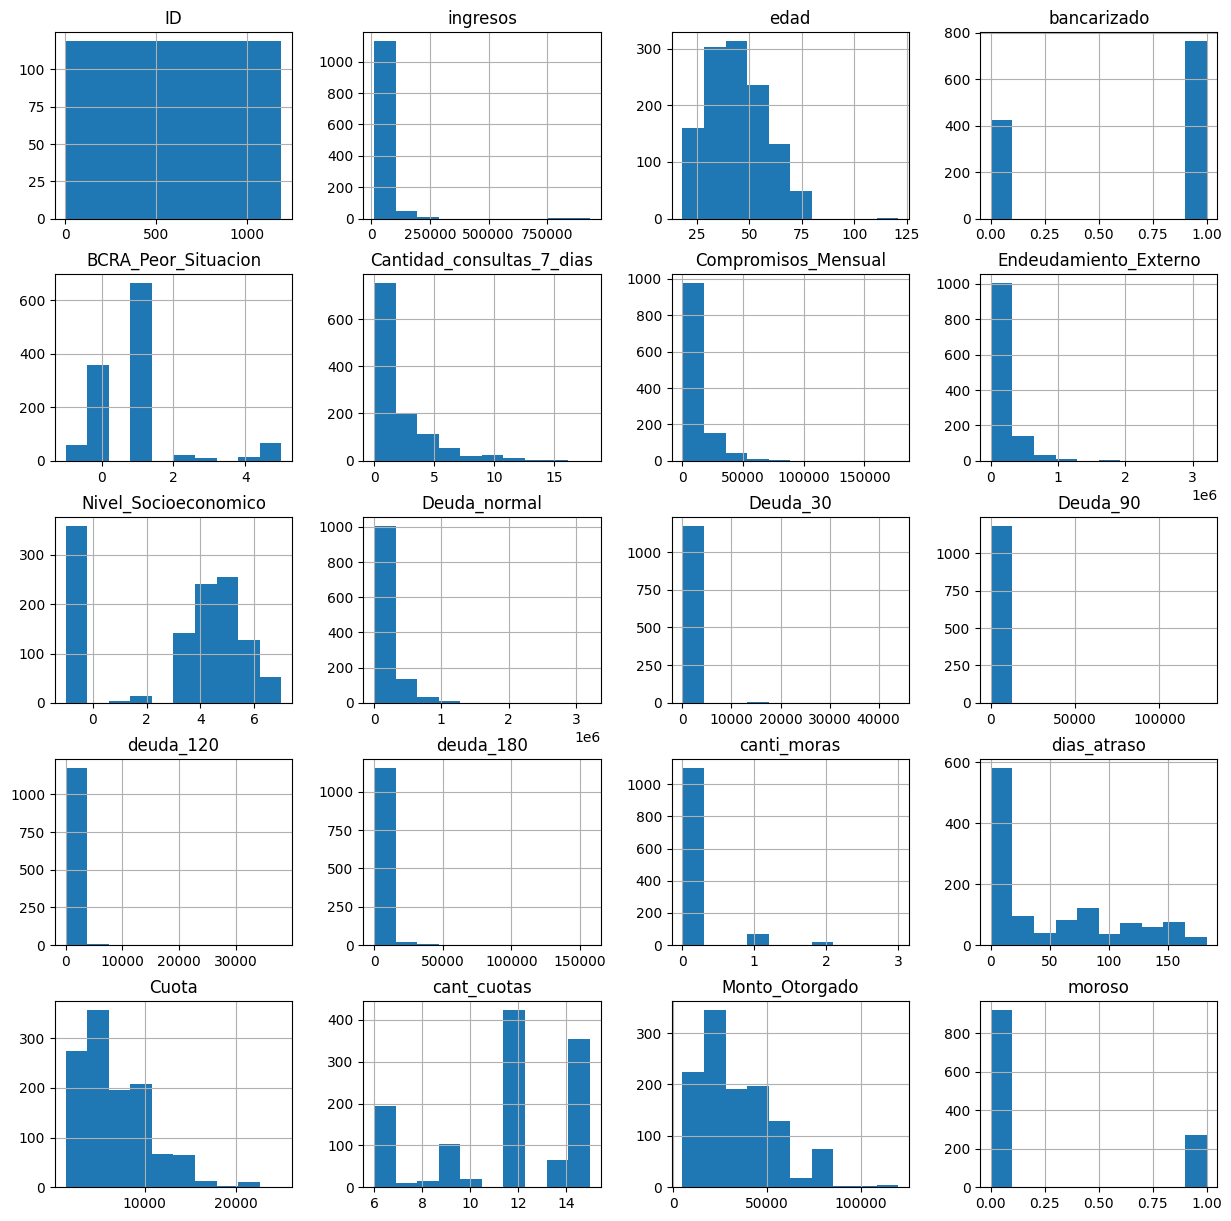

In [23]:
creditos.hist(bins=10, figsize=(15, 15))

In [28]:
# Creamos una lista con las variables de interés para el análisis exploratorio y la visualización.
variables_revision = [
    "edad", "ingresos", "Compromisos_Mensual", "Endeudamiento_Externo",
    "canti_moras", "dias_atraso", "Cuota", "Monto_Otorgado",
]

# Filtramos las variables de interés para el análisis exploratorio y la visualización.
creditos[variables_revision].describe()

,edad,ingresos,Compromisos_Mensual,Endeudamiento_Externo,canti_moras,dias_atraso,Cuota,Monto_Otorgado
count,1190.000000,1190.000000,1190.000000,1.190000e+03,1190.000000,1190.000000,1190.00000,1190.000000
mean,43.843697,53437.669538,9321.036134,1.526210e+05,0.094118,47.553782,6756.26705,34026.899269
std,13.781331,43665.378404,14235.963408,2.406785e+05,0.359257,56.008605,3738.92712,20263.219795
min,18.000000,12924.000000,0.000000,0.000000e+00,0.000000,0.000000,1350.90000,5000.000000
25%,33.000000,33539.617500,0.000000,0.000000e+00,0.000000,0.000000,3851.39000,19981.250000
50%,42.000000,47000.000000,3639.000000,5.401150e+04,0.000000,23.000000,5699.62000,28000.000000
75%,53.000000,63000.000000,13106.000000,2.270612e+05,0.000000,89.000000,8757.73000,50000.000000
max,121.000000,930000.000000,177911.000000,3.206484e+06,3.000000,183.000000,24934.57000,120000.000000


In [29]:
# Verificamos la cantidad de categorías únicas en cada columna de texto/categoría.
etiquetas_unicas = creditos[columnas_texto].nunique()

etiquetas_unicas = etiquetas_unicas.sort_values(ascending=False)

print("Cantidad de categorías en las columnas de texto:")
etiquetas_unicas

Cantidad de categorías en las columnas de texto:


relacion_dependencia    198
provincia_codigo         23
PROVINCIA                23
PRODUCTO                  7
autonomo                  3
Es_jubilado               3
dtype: int64

### 2.4 Distribución de la variable objetivo

Por último, verificamos cuántos casos hay de cada clase. Si una clase es mucho más frecuente, la *accuracy* puede parecer buena aunque el modelo ignore la clase menos común. Por eso, además de accuracy, después leeremos la matriz de confusión.

In [30]:
distribucion_objetivo = creditos["moroso"].value_counts()

resumen_objetivo = pd.DataFrame({
    "cantidad": distribucion_objetivo,
    "porcentaje": (distribucion_objetivo / len(creditos) * 100).round(1),
})

display(resumen_objetivo)

print("Conclusión del EDA:")
print("• Hay variables numéricas y categóricas; en este primer KNN usaremos solo las numéricas.")
print("• Los faltantes numéricos se imputarán con la mediana dentro del Pipeline.")
print("• Las clases no están balanceadas, así que evaluaremos también los errores por clase.")

,cantidad,porcentaje
moroso,,
0,921,77.4
1,269,22.6


Conclusión del EDA:
• Hay variables numéricas y categóricas; en este primer KNN usaremos solo las numéricas.
• Los faltantes numéricos se imputarán con la mediana dentro del Pipeline.
• Las clases no están balanceadas, así que evaluaremos también los errores por clase.


---
## 3. Visualizar antes de entrenar

Un buen hábito: **mirar los datos antes de entrenar cualquier modelo**. En este gráfico cada punto es una solicitud. La escala logarítmica en deuda permite ver mejor los casos con montos muy diferentes.

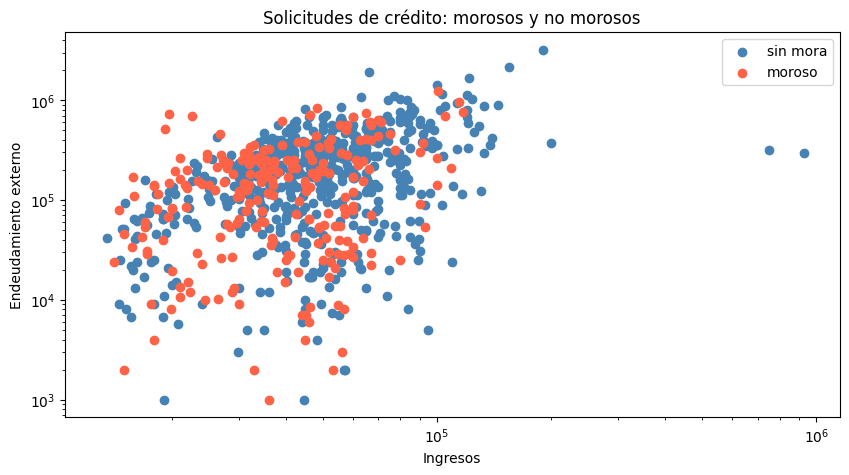

In [ ]:
# Definimos colores y etiquetas para la visualización de morosos y no morosos.
colores = {0: "steelblue", 1: "tomato"}
etiquetas = {0: "sin mora", 1: "moroso"}

# Generamos un gráfico de dispersión de ingresos vs. endeudamiento externo.
fig, ax = plt.subplots(figsize=(10, 5))
for clase, grupo in creditos.groupby("moroso"):
    ax.scatter(
        grupo["ingresos"], grupo["Endeudamiento_Externo"],
        label=etiquetas[clase], color=colores[clase]
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Ingresos")
ax.set_ylabel("Endeudamiento externo")
ax.set_title("Solicitudes de crédito: morosos y no morosos")
ax.legend()
plt.show()

---
## 4. Preparar los datos y entrenar un KNN

KNN decide según las distancias entre casos. Por eso las variables deben estar en una escala comparable: los ingresos están en miles, mientras que la edad está en decenas. 

Usamos un `Pipeline` que primero completa valores faltantes con la mediana, luego estandariza y finalmente entrena el clasificador.

Dejamos fuera `ID`, porque identifica una fila y no describe a la persona. También dejamos las columnas de texto para una clase posterior, donde veremos cómo codificarlas.

In [41]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Definimos las variables predictoras.
variables = [
    "ingresos", "edad", "BCRA_Peor_Situacion",
    "Cantidad_consultas_7_dias", "Compromisos_Mensual",
    "Endeudamiento_Externo", "canti_moras", "dias_atraso",
    "Cuota", "cant_cuotas", "Monto_Otorgado",
]

X = creditos[variables] # Variables predictoras
y = creditos["moroso"]  # Variable objetivo

# Dividimos el dataset en train y test, estratificando por la variable objetivo.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Creamos un Pipeline que imputa los valores faltantes con la mediana, estandariza las variables y aplica KNN.
modelo = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=7)),
])

# Entrenamos el modelo con los datos de entrenamiento
modelo.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de prueba.
y_pred = modelo.predict(X_test)

print(f"Train: {X_train.shape[0]} solicitudes — Test: {X_test.shape[0]} solicitudes")
print("Primeras predicciones:", y_pred[:10])

Train: 892 solicitudes — Test: 298 solicitudes
Primeras predicciones: [0 0 0 0 0 1 0 0 0 0]


---
## 5. La matriz de confusión, como gráfico

La accuracy sola puede engañarnos cuando hay muchas más solicitudes no morosas que morosas. La matriz de confusión muestra qué tipo de errores está cometiendo el modelo. En un caso real, decidir cuál error es más costoso requiere criterios del negocio y revisión humana.

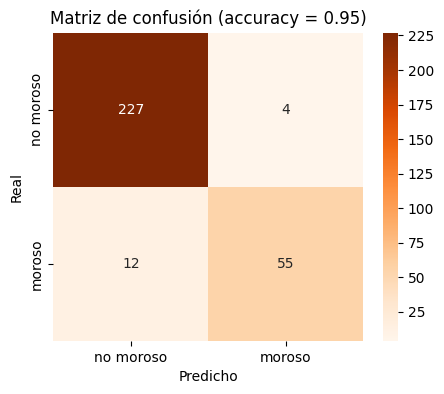

In [42]:
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

exactitud = accuracy_score(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matriz, annot=True, fmt="d", cmap="Oranges",
    xticklabels=["no moroso", "moroso"],
    yticklabels=["no moroso", "moroso"], ax=ax,
)
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title(f"Matriz de confusión (accuracy = {exactitud:.2f})")
plt.show()

---
## 📝 Actividad — Clasificá una nueva solicitud

**Consigna:**
- Elegí valores plausibles para una nueva solicitud.
- Pedile al modelo que prediga si será `moroso` o `no moroso`.
- Probá cambiar solo `dias_atraso`, `canti_moras` o `Endeudamiento_Externo` y observá si cambia el resultado.


In [ ]:
# ACTIVIDAD: cambiar los valores de esta nueva solicitud
nueva_solicitud = pd.DataFrame([{
    "ingresos": 50000,
    "edad": 35,
    "BCRA_Peor_Situacion": 1,                   # Va desde 1 (sin mora) hasta 5 (incobrable)
    "Cantidad_consultas_7_dias": 2,
    "Compromisos_Mensual": 9000,
    "Endeudamiento_Externo": 80000,
    "canti_moras": 0,                          # Cantidad de moras en el historial crediticio
    "dias_atraso": 0,
    "Cuota": 5000,
    "cant_cuotas": 12,
    "Monto_Otorgado": 30000,
}])

prediccion = modelo.predict(nueva_solicitud)[0]
probabilidad = modelo.predict_proba(nueva_solicitud)[0, 1]

print("Predicción:", etiquetas[prediccion])
print(f"Proporción de vecinos morosos: {probabilidad:.0%}")